In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from stoneforge.data_management.preprocessing import DataLoader, DataManager
from stoneforge.inversion.mineralogical.multimineral import MineralDatabase, MultimineralInversion
from stoneforge.vis.img import fastplot

In [5]:
# Accessing Internal Dataframe for MP_56D Well

DATA = DataLoader(r"https://raw.githubusercontent.com/giecaruff/datasets/refs/heads/main/wells/las2/massape/7-MP-56D-BA.las", filetype='las2')
data_MP_56D, units_MP_56D = DATA.dataframe(DATA.data_obj.data)
data_MP_56D

,DEPTH,BS,GR,CALI,DT,RT30,RT60,RT90,RHOB,DRHO,NPHI
0,1868.0001,8.5,96.0140,9.6470,91.3812,2.4726,2.4300,2.4973,NaN,NaN,NaN
1,1868.1001,8.5,96.2027,9.5881,91.0722,2.4536,2.4127,2.4801,2.4487,0.1205,0.2884
2,1868.2001,8.5,97.7789,9.5809,90.1369,2.4079,2.3687,2.4348,2.4563,0.0974,0.2830
3,1868.3001,8.5,98.0069,9.5892,89.3943,2.3368,2.3003,2.3639,2.4703,0.0721,0.2830
4,1868.4001,8.5,98.5336,9.4958,89.6868,2.1647,2.1346,2.1917,2.5003,0.0396,0.2731
...,...,...,...,...,...,...,...,...,...,...,...
13045,3172.5001,8.5,87.5305,7.2086,66.0265,12.3590,12.2146,12.0041,2.3356,0.1072,0.1468
13046,3172.6001,8.5,88.2076,7.2082,65.5312,12.3572,12.1929,11.9750,2.3341,0.1086,0.1477
13047,3172.7001,8.5,89.5980,7.2113,65.9171,12.3821,12.1954,11.9688,2.3339,0.1109,0.1504
13048,3172.8001,8.5,91.4339,7.2124,66.3742,12.7422,12.4908,12.2348,2.3376,0.1160,0.1495


In [6]:
# Removing specific values
# OBS: you can use "df.dropna(inplace=True)" to remove all np.nan values

data_MP_56D_c = data_MP_56D[~data_MP_56D.isin([-999.0]).any(axis=1)]
data_MP_56D_c

# Taking specific range in depth for analysis (reservoir interval)

RESERVOIR = data_MP_56D_c[data_MP_56D_c['DEPTH'].between(2800, 3200)]

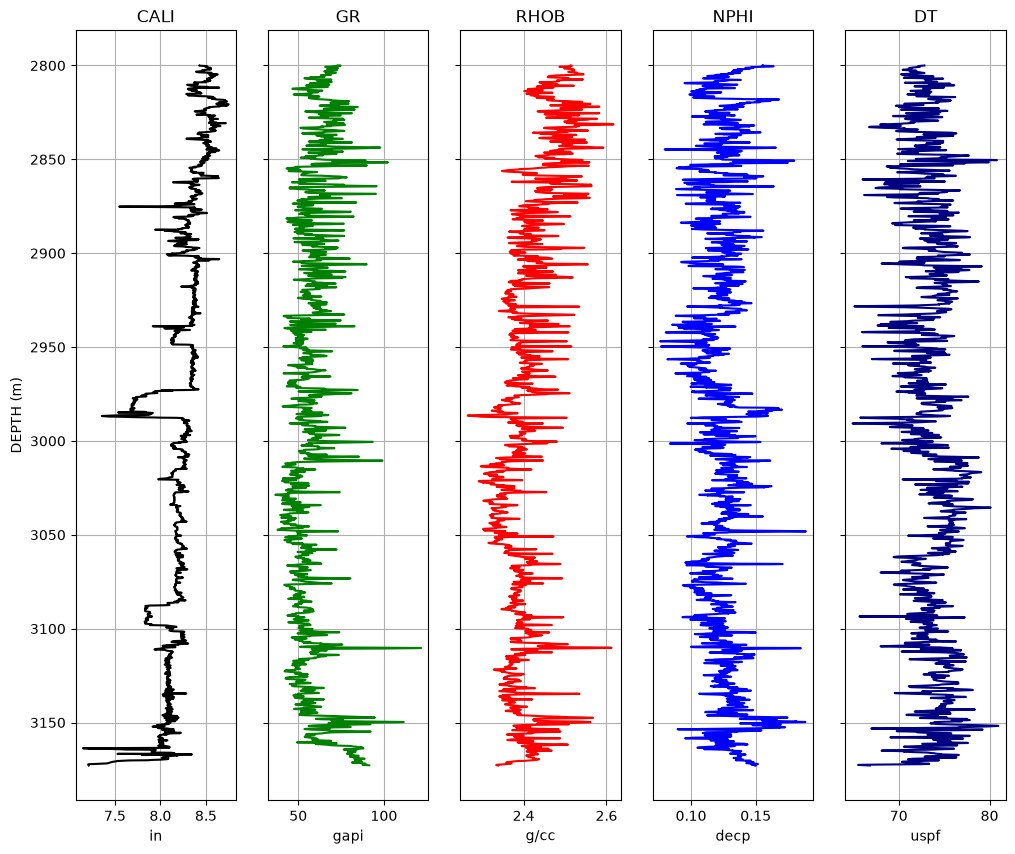

In [9]:
# Viewing Well Log Data

curves = ["CALI","GR","RHOB","NPHI","DT"]
units = []
for c in curves:
    units.append(units_MP_56D[c])

color = ["k","g","r","b","navy"]

fastplot(RESERVOIR,"DEPTH",curves, color, units, d_unit='m')

In [ ]:
# Mineralogical / Petrophysical Reference

mineral_dict = {
    "QUARTZ": {"GR": 20.0, "DT": 55.5, "RHOB": 2.650, "NPHI": 0.00, "ONES": 1.0},
    "CALCITE": {"GR": 11.0, "DT": 47.8, "RHOB": 2.710, "NPHI": 0.00, "ONES": 1.0},
    "SHALE": {"GR": 111.0, "DT": 100.0, "RHOB": 2.657, "NPHI": 0.48, "ONES": 1.0},
    "ARKOSE": {"GR": 160.0, "DT": 130.0, "RHOB": 2.560, "NPHI": 0.40, "ONES": 1.0},
    "FLUID": {"GR": 0.0001, "DT": 185.0, "RHOB": 1.100, "NPHI": 1.00, "ONES": 1.0}
}

RESERVOIR

,DEPTH,BS,GR,CALI,DT,RT30,RT60,RT90,RHOB,DRHO,NPHI
9320,2800.0001,8.5,72.9283,8.4278,72.8240,10.6514,10.7760,10.6847,2.5128,0.0065,0.1554
9321,2800.1001,8.5,74.7365,8.4298,72.5574,10.6684,10.7955,10.7156,2.5130,0.0062,0.1548
9322,2800.2001,8.5,73.8403,8.4827,72.3741,10.6459,10.7734,10.6996,2.5166,0.0059,0.1576
9323,2800.3001,8.5,72.1697,8.5061,72.1571,10.6061,10.7334,10.6660,2.5155,0.0058,0.1629
9324,2800.4001,8.5,70.2593,8.5054,72.1145,10.5172,10.6436,10.5888,2.5113,0.0044,0.1638
...,...,...,...,...,...,...,...,...,...,...,...
13045,3172.5001,8.5,87.5305,7.2086,66.0265,12.3590,12.2146,12.0041,2.3356,0.1072,0.1468
13046,3172.6001,8.5,88.2076,7.2082,65.5312,12.3572,12.1929,11.9750,2.3341,0.1086,0.1477
13047,3172.7001,8.5,89.5980,7.2113,65.9171,12.3821,12.1954,11.9688,2.3339,0.1109,0.1504
13048,3172.8001,8.5,91.4339,7.2124,66.3742,12.7422,12.4908,12.2348,2.3376,0.1160,0.1495


In [ ]:
# Calculation and data organization

db = MineralDatabase(mineral_dict)

elan = MultimineralInversion(RESERVOIR)

res_1 = elan.solve(
    db=db,
    active_logs=["GR", "DT", "RHOB", "NPHI"],
    active_minerals=["QUARTZ", "SHALE", "FLUID"],
)
print("--- Scenario 1 Results ---")
print(res_1)

RESERVOIR['QUARTZ'] = np.array(res_1['QUARTZ'])
RESERVOIR['SHALE'] = np.array(res_1['SHALE'])
RESERVOIR['FLUID'] = np.array(res_1['FLUID'])


--- Scenario 1 Results ---
         QUARTZ     SHALE  FLUID
9320   0.398602  0.601398    0.0
9321   0.381287  0.618713    0.0
9322   0.391596  0.608404    0.0
9323   0.408104  0.591896    0.0
9324   0.425997  0.574003    0.0
...         ...       ...    ...
13045  0.206923  0.793077    0.0
13046  0.200902  0.799098    0.0
13047  0.185818  0.814182    0.0
13048  0.168007  0.831993    0.0
13049       NaN       NaN    NaN

[3730 rows x 3 columns]


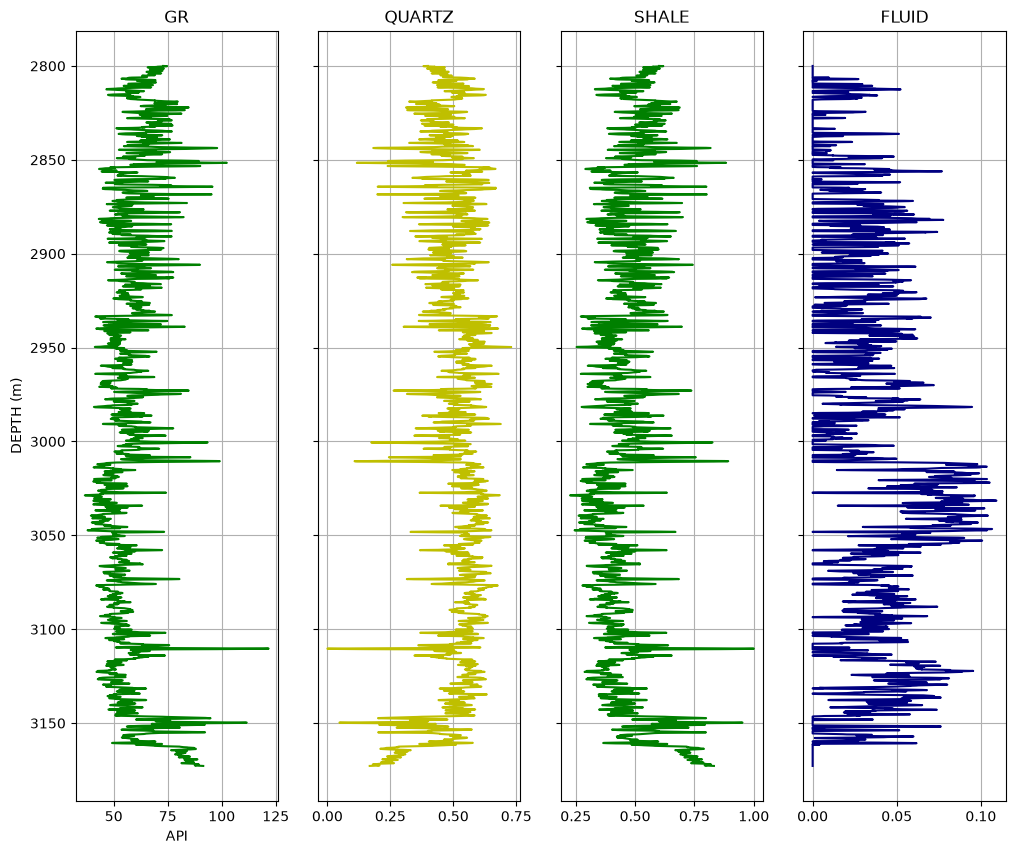

In [ ]:
# Viewing final Data

curves = ["GR","QUARTZ","SHALE","FLUID"]
units = ["API","","",""]

color = ["g","y","g","navy"]

fastplot(RESERVOIR,"DEPTH",curves, color, units, d_unit='m')